In [73]:
import pandas as pd
import numpy as np
import kagglehub as kaghub
import tiktoken

In [74]:
# Downloading "SMS SPAM" dataset from kaggle
# df_path = kaghub.dataset_download("uciml/sms-spam-collection-dataset")
# df_path, it prints: ('C:\\Users\\harde\\.cache\\kagglehub\\datasets\\uciml\\sms-spam-collection-dataset\\versions\\1')

In [75]:
spam_df = pd.read_csv("C:\\Users\\harde\\Documents\\LLMs (GEN AI)\\SMS SPAM Detection using LLM\\sms+spam+collection\\SMSSpamCollection", sep="\t", header=None, names=["Label", "Text"])
spam_df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [76]:
# Making a copy of the data
df = spam_df.copy(deep = True)
df.shape

(5572, 2)

In [77]:
df['Label'].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [78]:
# Let's create a balanced dataset and take only 747 "ham" from 4825 "ham" data rows

def create_balanced_dataset(df):
  # Count number of "spam"
  num_spam = df[df['Label'] == 'spam'].shape[0]

  # Randomly sample 'ham' instances to match the number of 'spam' instances
  ham_subset = df[df['Label'] == 'ham'].sample(num_spam,random_state = 123)

  # Combine ham 'subset' with 'spam'
  baln_df = pd.concat([ham_subset,df[df['Label'] == 'spam']])

  return baln_df

bal_df = create_balanced_dataset(df)
bal_df['Label'].value_counts()

Label
ham     747
spam    747
Name: count, dtype: int64

In [79]:
# Let's map the 'spam' to 1 and 'ham' to 0
bal_df['Label'] = bal_df['Label'].map({'ham':0,'spam':1})

In [80]:
bal_df['Label'].value_counts()

Label
0    747
1    747
Name: count, dtype: int64

In [81]:
# Let's divide our dataset for training(70%), testing(20%), and Validation(10%)
def random_split(df, train_frac,validation_frac):
  # Shuffling the entire Dataset
  df = df.sample(frac = 1, random_state = 123).reset_index(drop = True)

  # Calculate split indices 
  train_end = int(len(df) * train_frac)
  validation_end = train_end + int(len(df) * validation_frac)

  # Split the dataframe
  train_df = df[:train_end]
  validation_df = df[train_end:validation_end]
  test_df = df[validation_end:]

  return train_df, validation_df, test_df

train_df, val_df, test_df = random_split(bal_df,0.7,0.1)

In [82]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

1045
149
300


In [83]:
# Saving all the dfs' to the folder
train_df.to_csv("train.csv",index = None)
val_df.to_csv("validation.csv",index = None)
test_df.to_csv("test.csv", index = None)

In [84]:
# Here in order to load the dataset using 'datasets' & 'dataloader', we need to have the same size of tokens in all the emails in every batch, for which we
# will be doing padding of "EndofText" token number to all the shorter token embeddings of emails which would be smaller as compared to largest email token embedding.

### CREATING DATALOADER

In [85]:
# Defining tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

In [86]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_length = None, pad_token_id = 50256):
    self.data = pd.read_csv(csv_file)

    # Pre-tokenize texts
    self.encoded_texts = [tokenizer.encode(text) for text in self.data['Text']]

    if max_length is None:
      self.max_length = self._longest_encoded_length()
    else:
      self.max_length = max_length

      # Truncate sequence if they are longer then max length
      self.encoded_texts = [encoded_text[:max_length] for encoded_text in self.encoded_texts]

    # Pad the sequences to the longest sequence
    self.encoded_texts = [encoded_text + [pad_token_id] * (self.max_length - len(encoded_text)) for encoded_text in self.encoded_texts]

  def __getitem__(self,index):
    encoded = self.encoded_texts[index]
    label = self.data.iloc[index]["Label"]
    return (
        torch.tensor(encoded,dtype = torch.long),
        torch.tensor(label, dtype = torch.long)
    )

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_length = 0
    for encoded_text in self.encoded_texts:
      encoded_length = len(encoded_text)
      if encoded_length > max_length:
        max_length = encoded_length
    return max_length

In [87]:
# Let's use the above defined class for making train_dataset, val_dataset and test_dataset
train_dataset = SpamDataset(csv_file = "train.csv", max_length = None, tokenizer = tokenizer)

# Now let's prepare dataset for testing and validation
val_dataset = SpamDataset(csv_file = "validation.csv",
                          max_length = train_dataset.max_length,
                          tokenizer = tokenizer)

test_dataset = SpamDataset(csv_file = "test.csv",
                           max_length = train_dataset.max_length,
                           tokenizer = tokenizer)

In [88]:
print(f"Training Dataset Length: {train_dataset.max_length}")
print(f"Validation Dataset Length: {val_dataset.max_length}")
print(f"Testing Dataset Length: {test_dataset.max_length}")

Training Dataset Length: 120
Validation Dataset Length: 120
Testing Dataset Length: 120


In [89]:
# Defining the new configurations based on downlaoded weights
# Changing two things: {context_length,qkv_bias}
NEW_CONFIG = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim":768,            # Embedding dimension
    "n_heads":12,             # number of attentions heads in Multi-head Attention function
    "n_layers":12,            # number of transformer blocks
    "drop_rate":0.0,          # dropout rate of the neurons
    "qkv_bias":True          # Query-Key-Value bias
}

In [90]:
# Setting up a Assertion which is checking the input context_length should be less then or equal to GPT2(124M) model's context_length which is 1024
assert train_dataset.max_length <= NEW_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {NEW_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={NEW_CONFIG['context_length']}`"
)

In [91]:
# Let's use created 'Dataset' and instantiate 'DataLoader'
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8 # Number of SMS in a batch with target

torch.manual_seed(123)

# Training DataLoader
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = True
)

# Testing DataLoader
test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = False
)

# Validation DataLoader
val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    shuffle = True,
    num_workers=num_workers,
    drop_last = False
)


In [92]:
print("Train Loader:")
for input_batch,target_batch in train_loader:
  pass

print("Input batch dimension:", input_batch.shape)
print("Label batch dimension:", target_batch.shape)

Train Loader:
Input batch dimension: torch.Size([8, 120])
Label batch dimension: torch.Size([8])


In [93]:
print(f"{len(train_loader)} training batches")    # 70% data
print(f"{len(val_loader)} validation batches")    # 10% data
print(f"{len(test_loader)} test batches")         # 20% data

130 training batches
19 validation batches
38 test batches


#### Step 01: Loading Pretrained LLM Model with GPT2 weights

##### Defining Class & Methods in which stored model parameters and optimizer will be loaded

In [94]:
# Device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Chosen Processing Unit : {device}")

Chosen Processing Unit : cuda


In [95]:
import torch.nn as nn
import torch

# # Why we do Layer Normalization? , Ans: We need to take care of vanishing or exploding gradient problem and also reduces problem of "internal covariate shift" in the input inbetween the layers, this helps in accelerate convergence & we get to result faster.
# # Main Idea: Adjust outputs of neural network to have mean zero and variance of one (helps in speeding up the convergence)
# Now let's define the normalization class
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self,input):
    mean = input.mean(dim = -1,keepdim = True)
    variance = input.var(dim = -1, keepdim = True, unbiased = False)
    normalized_output = (input - mean) / torch.sqrt(variance + self.eps)
    return self.scale * normalized_output + self.shift

class GELU(nn.Module):
  def __init___(self):
    super().__init__()

  def forward(self,input):
    return 0.5 * input * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (input + 0.044715 * torch.pow(input,3))))


# let's now create a FeedForward neural network class
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),      # Expansion
        GELU(),   # GELU Activation
        nn.Linear(4 * cfg['emb_dim'],cfg['emb_dim'])    # Contraction
        )

  def forward(self,input):
    return self.layers(input)

# Let's make a "Multi-head Attention Class"
import torch.nn as nn
class MultiHeadAttention(nn.Module):

  def __init__(self,d_in,d_out,context_length,dropout, num_heads, qkv_bias = False):
    super().__init__()
    assert(d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_in = d_in
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim
    self.W_query = nn.Linear(d_in,d_out,bias = qkv_bias)    # Wq
    self.W_key = nn.Linear(d_in,d_out,bias = qkv_bias)    #Wk
    self.W_value = nn.Linear(d_in,d_out,bias = qkv_bias)  #W
    self.out_proj = nn.Linear(d_out,d_out)  # Linear layer to combine heads outputs
    self.dropout = nn.Dropout(dropout)    # dropout gives us the percentage of dropout to be applied on matrix
    self.register_buffer(
        "mask",torch.triu(torch.ones(context_length,context_length), diagonal = 1)
    )

  def forward(self,input):
    b,num_tokens,d_in = input.shape

    keys = self.W_key(input)
    queries = self.W_query(input)
    values = self.W_value(input)

    # We implicitly split the matrix by adding a 'num-heads' dimension
    # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    keys = keys.view(b,num_tokens,self.num_heads,self.head_dim)
    values = values.view(b,num_tokens,self.num_heads,self.head_dim)
    queries = queries.view(b,num_tokens, self.num_heads, self.head_dim)

    # Transpose : (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1,2)    # transposing only num_tokens & num_heads
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    # Compute sclaed dot-product attention (aka self-attention) with a causal mask
    atten_score = queries @ keys.transpose(2,3)

    # Original mask truncated to the number of tokens and converted to boolean
    mask_bool = self.mask.bool()[:num_tokens,:num_tokens]

    # Use the mask to fill attention score
    atten_score.masked_fill_(mask_bool, -torch.inf)

    atten_weights = torch.softmax(atten_score / keys.shape[-1] ** 0.5, dim = -1)  # dim = -1, as we have to make sure that sum of all the rows should sum upto 1
    atten_weights = self.dropout(atten_weights)

    # context_embedding_vector Shape: (b,num_tokens,num_heads, num_dim)
    context_embedding_vector = (atten_weights @ values).transpose(1,2)

    # Combine heads, where self.d_out = self.num_heads * self.head_dim
    context_embedding_vector = context_embedding_vector.contiguous().view(b,num_tokens, self.d_out)
    context_embedding_vector = self.out_proj(context_embedding_vector)  # Optional Projection

    return context_embedding_vector

class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.multihead_attention = MultiHeadAttention(
        d_in = cfg['emb_dim'],
        d_out = cfg['emb_dim'],
        context_length = cfg['context_length'],
        dropout = cfg['drop_rate'],
        num_heads = cfg['n_heads'],
        qkv_bias = cfg['qkv_bias']
    )
    self.feedforward = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg['emb_dim'])
    self.norm2 = LayerNorm(cfg['emb_dim'])
    self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self,input):
    # Shortcut connection for attention block
    original_input = input
    input = self.norm1(input)
    input = self.multihead_attention(input)    # Shape[batch_size,num_tokens, emb_size]
    input = self.drop_shortcut(input) # Avoid gradient diminshing problem
    input = input + original_input   # Add the original input back

    # ShortCut connection for Feed Forward block
    original_input = input
    input = self.norm2(input)
    input = self.feedforward(input)
    input = self.drop_shortcut(input)
    input = input + original_input    # Add the original input back
    output = input
    return output

# Let's us a make a GPT Model Class

class GPTModel(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
    self.pos_emb = nn.Embedding(cfg['context_length'],cfg['emb_dim'])
    self.dropout = nn.Dropout(cfg['drop_rate'])

    self.Transformer_Blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg['n_layers'])])

    self.final_norm = LayerNorm(cfg['emb_dim'])
    self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'],bias = False)

  # Input passsed: "Every effort moves you"
  def forward(self,input_token_ids):
    batch_size, seq_len = input_token_ids.shape
    token_embeddings = self.tok_emb(input_token_ids)
    position_embeddings = self.pos_emb(torch.arange(seq_len,device = input_token_ids.device))
    embedding_vector = token_embeddings + position_embeddings
    embedding_vector = self.dropout(embedding_vector)    # Helps for avoiding overfitting
    embedding_vector = self.Transformer_Blocks(embedding_vector)
    embedding_vector = self.final_norm(embedding_vector)
    logits = self.out_head(embedding_vector)
    return logits


# Let's define a function based on our steps till now to predict new words/tokens
# eos_id = End of Sample Id
def generate_new_tokens(model, idx, max_new_tokens, context_size, temp = 0.0, top_k = None, eos_id = None):
  # For_loop is same as before : Get_Logits, and only focus on last time step
  for _ in range(max_new_tokens):
    idx_cond = idx[:,-context_size:]
    with torch.no_grad():
      logits = model(idx_cond)
    logits = logits[:,-1,:]

    # New: Filter logits with top_k sampling
    if top_k is not None:
      # Keep only top_k values
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:,-1]
      logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), other = logits)

    # New: Apply temperature scaling
    if temp > 0.0:
      logits = logits / temp
      probs = torch.softmax(logits, dim = -1) # Applying Softmax to get logits into probabilities
      idx_next = torch.multinomial(probs, num_samples = 1) # Sample from the distribution

    # Otherwise don't change anything in logits, just apply Softmax
    else:
      probs = torch.softmax(logits,dim = -1)
      idx_next = torch.argmax(probs, dim = -1, keepdim = True)

    if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered
      break

    # Same as before: append predicted index to the running sequence
    idx = torch.cat((idx, idx_next), dim =1)  # Shape : {Batch_size, num_tokens + 1}

  return idx

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)   # added batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())



##### Loading our stored Pretrained LLM Model into defined Class "GPTModel" with defined "NEW_CONFIG"

In [96]:
import requests
import os
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M","355M","774M","1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json","hparams.json","model.ckpt.data-00000-of-00001","model.ckpt.index","model.ckpt.meta","vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir,exist_ok = True)
    for filename in filenames:
        file_url = os.path.join(base_url,model_size, filename)
        file_path = os.path.join(model_dir,filename)
        download_file(file_url,file_path)


    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [97]:
# We are running and storing the params of gpt-2 "124M para" in two variables
settings, params = download_and_load_gpt2(model_size = "124M" , models_dir = "gpt2")

C:\Users\harde\anaconda3\lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\checkpoint


C:\Users\harde\anaconda3\lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\encoder.json


C:\Users\harde\anaconda3\lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: gpt2\124M\model.ckpt.index


C:\Users\harde\anaconda3\lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\model.ckpt.meta


C:\Users\harde\anaconda3\lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [98]:
print("Settings: ", settings)
print("Parameters dictionary keys: ", params.keys())

Settings:  {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameters dictionary keys:  dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [99]:
# Define a function for assigning the weights/parameter values after comparing the requirements
def assign(left, right):
  if left.shape != right.shape:   # Checking the shape and size of weights to be replaced
    raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

In [100]:
# Define a function for loading the pre-trained weights from gpt2 into our own created model
import numpy as np

def load_weights_into_gpt(gpt,params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

  for b in range(len(params['blocks'])):
    # Separating query,key, value weights matrices of gpt-2(124M)
    q_w,k_w, v_w = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis = -1)

    # Updating the transformer blocks query,key,value weights matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.weight, q_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.weight, k_w.T)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.weight, v_w.T)

    # Separating query,key,value bias matrices of gpt-2(124M)
    q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis = -1)

    # Updating the transformer blocks query,key,value bias matrices with gpt-2 downloaded ones which are getting separated above
    gpt.Transformer_Blocks[b].multihead_attention.W_query.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_query.bias, q_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_key.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_key.bias, k_b)
    gpt.Transformer_Blocks[b].multihead_attention.W_value.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.W_value.bias, v_b)

    # Updating the "out_proj" matrix weights with gpt-2 ones
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias = assign(gpt.Transformer_Blocks[b].multihead_attention.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])

    # Updating the "FeedForward" matrices of layer0, layer2 with gpt-2 ones
    gpt.Transformer_Blocks[b].feedforward.layers[0].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[0].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])

    gpt.Transformer_Blocks[b].feedforward.layers[2].weight = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.Transformer_Blocks[b].feedforward.layers[2].bias = assign(gpt.Transformer_Blocks[b].feedforward.layers[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])

    # Updating the "LayerNorm" matrices of norm1, norm2 with gpt-2 ones
    gpt.Transformer_Blocks[b].norm1.scale = assign(gpt.Transformer_Blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
    gpt.Transformer_Blocks[b].norm1.shift = assign(gpt.Transformer_Blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])

    gpt.Transformer_Blocks[b].norm2.scale = assign(gpt.Transformer_Blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
    gpt.Transformer_Blocks[b].norm2.shift = assign(gpt.Transformer_Blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

  gpt.final_norm.scale = assign(gpt.final_norm.scale,params["g"])
  gpt.final_norm.shift = assign(gpt.final_norm.shift,params["b"])
  gpt.out_head.weight = assign(gpt.out_head.weight,params["wte"])  # Same token embedding weights have been used for replacing weight for this layer


In [101]:
# Checking the configuration for the model
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.0,
 'qkv_bias': True}

In [102]:
# Updating the defined class of GPT model architecture with GPT-2 Pre-trained weights
model = GPTModel(NEW_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

In [103]:
# Now let's see the output of our model
output_token_ids = generate_new_tokens(model = model,
    idx = text_to_token_ids("Hardeep is a genius why?", tokenizer),
    max_new_tokens = 20,
    context_size = NEW_CONFIG['context_length'],
    top_k = 50,
    temp = 1.5
)

print("\n Output After Scaling: \n", token_ids_to_text(output_token_ids,tokenizer))


 Output After Scaling: 
 Hardeep is a genius why?


Thanks so much! Also that was awesome I have to mention some of the features that I


In [104]:
NEW_CONFIG = {
    "vocab_size": 50257,      # Vocabulary size
    "context_length": 1024,   # Context length
    "emb_dim":768,            # Embedding dimension
    "n_heads":12,             # number of attentions heads in Multi-head Attention function
    "n_layers":12,            # number of transformer blocks
    "drop_rate":0.0,          # dropout rate of the neurons
    "qkv_bias":True          # Query-Key-Value bias
}
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.0,
 'qkv_bias': True}

In [105]:
# let's check how our model will behave now for a Spam SMS classification
model.to(device)    # Setting model to 'cuda' gpu device
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    "'you are a winner you have been specially"
    " selected to receive Rs.50000 cash.'"
)

output_token_ids = generate_new_tokens(
    model = model,
    idx = text_to_token_ids(text_2,tokenizer).to(device),
    max_new_tokens=23,
    context_size=NEW_CONFIG['context_length']
)

print(token_ids_to_text(output_token_ids,tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no':'you are a winner you have been specially selected to receive Rs.50000 cash.'

The scam is not limited to the Indian market. In fact, it is spreading across the world.



In [106]:
# Checking the Model layers status 
for name,param in model.named_parameters():
    print(f"Layer: {name} || Trainable: {param.requires_grad}")

Layer: tok_emb.weight || Trainable: True
Layer: pos_emb.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight || Trainable: True
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.0.weight || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.0.bias || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.2.weight || Trainable: True
Layer: Transformer_Blocks.0.feedforward.layers.2.

In [107]:
# We Need to freeze all the layers of the imported model and later we can unfreeze whichever is required
for param in model.parameters():
    param.requires_grad = False

In [122]:
# Checking the Model layers status  
for name,param in model.named_parameters():
    print(f"Layer: {name} || Trainable: {param.requires_grad}")

Layer: tok_emb.weight || Trainable: False
Layer: pos_emb.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.2.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforw

#### Step 02: Modifying the architecture by adding a classification head

In [109]:
# Let's see our LLM Model structure
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.0, inplace=False)
  (Transformer_Blocks): Sequential(
    (0): TransformerBlock(
      (multihead_attention): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (feedforward): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (multihead_attention): MultiHeadAt

In [110]:
# We will be changing the "out head's" out_features from 50257 to 2 ("yes","no") as we have only two classification to be made

torch.manual_seed(123)

num_target_classes = 2  # {"SPAM" & "HAM"}
model.out_head = torch.nn.Linear(in_features= NEW_CONFIG['emb_dim'], out_features=num_target_classes).to(device)

#### Step 03: Select which layers to be fine-tuned?
We will fine-tune:
1.   Final output head
2.   Final transformer block
3.   Final LayerNorm module

In [111]:
# Now let's make the parameters of the last transformer and LayerNorm to be trainable

# Last transformer block
for param in model.Transformer_Blocks[-1:].parameters():
  param.requires_grad = True

# LayerNorm
for param in model.final_norm.parameters():
  param.requires_grad = True

In [112]:
# Checking the Model layers status 
for name,param in model.named_parameters():
    print(f"Layer: {name} || Trainable: {param.requires_grad}")

Layer: tok_emb.weight || Trainable: False
Layer: pos_emb.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.bias || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.2.weight || Trainable: False
Layer: Transformer_Blocks.0.feedforw

#### Step 04: Extract the last output token from all inputs tokens

In [113]:
input_text = "Do you have time"
inputs = text_to_token_ids(input_text,tokenizer).to(device)

In [114]:
with torch.no_grad():
  outputs = model(inputs)

print("Outputs: ", outputs, "\nShape: ",outputs.shape)
# We can see here we have only two outputs as expected

Outputs:  tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]], device='cuda:0') 
Shape:  torch.Size([1, 4, 2])


In [115]:
# Extracting the last last token
print("Last output token: ",outputs[:,-1,:])

Last output token:  tensor([[-3.5983,  3.9902]], device='cuda:0')


In [ ]:
# Let's convert the logits into probabilities
probas = torch.softmax(outputs[:,-1,:],dim = -1)
label = torch.argmax(probas)
print("Class Label:", label.item())

#### Step 05: Calculate the accuracy and classification loss

In [117]:
# Let's define a "Accuracy Calculation" method
def calc_accuracy_loader(data_loader,model,device,num_batches = None):
  model.eval();
  correct_predictions, num_examples = 0,0

  if num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      input_batch, target_batch = input_batch.to(device), target_batch.to(device)

      with torch.no_grad():
        logits = model(input_batch)[:,-1,:]   # Logits of the last output token
      predicted_labels = torch.argmax(torch.softmax(logits,dim = -1), dim = -1)

      num_examples += predicted_labels.shape[0]
      correct_predictions += (predicted_labels == target_batch).sum().item()
    else:
      break
  return correct_predictions / num_examples

In [118]:
# Now let's call this "calc_accuracy_loader" method for all three datasets
torch.manual_seed(123)

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches = 10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches = 10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches = 10)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 46.25%
Validation Accuracy: 53.75%
Test Accuracy: 50.00%


In [119]:
# Let's defined Loss Function for this ML Model which would be "Categorical Cross Entropy", formula : -Sum(Yi * log(Pi)), here i is the number of samples
def  calc_loss_batch(input_batch, target_batch, model, device):
  # Setting the device to deal with input,output data processing
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)

  logits = model(input_batch)[:,-1,:]   # Taking output logit of last token
  loss = torch.nn.functional.cross_entropy(logits,target_batch)
  return loss


# Defining "LOSS" function calculation method for multiple batches
def calc_loss_loader(data_loader,model,device,num_batches = None):
  total_loss = 0
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))

  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch,model,device)
      total_loss += loss.item()
    else:
      break
  return total_loss/num_batches

# Now let's call this "calc_loss_loader" method for all three datasets
torch.manual_seed(123)

with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device, num_batches = 5)
  val_loss = calc_loss_loader(val_loader, model, device, num_batches = 5)
  test_loss = calc_loss_loader(test_loader, model, device, num_batches = 5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 3.095
Validation loss: 2.464
Test loss: 2.812


#### Step 06: Finetune Model on Supervised Data
Define Training Loop

      Steps to be followed for training LLM model for a specific task:
      - For each training epoch
          - For each batch in training dataset
              - Reset the loss gradients from previous epoch
              - Calculate the loss on current batch
              - Backward pass to calculate the loss gradients  (finding partial differentiation of Loss function wrt weights)
              - Update model weights using loss gradients (finding & updating new weights based on formula: Weight_new = Weight_old - (Learning_rate * partial differentiation of Loss function wrt weights))
              - Print training and validation set losses
          - New: Calculate classification accuracy


In [120]:
# Defining the 'Evaluate Model' functions
def evaluate_model(model,train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches = eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches = eval_iter)
  model.train()
  return train_loss, val_loss

In [121]:
# Define LLM Model training function
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter):

  # Initialize lists to track losses and exampls seen
  train_losses,val_losses,train_accs, val_accs = [],[],[],[]
  examples_seen, global_step = 0,-1

  # Main training loop
  for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  # Reseting loss gradients from previous batch iteration
      loss = calc_loss_batch(input_batch, target_batch, model, device)    # Calculating loss
      loss.backward()  # Calculate the loss gradients
      optimizer.step()  # Updating model weights using loss gradients(found in above step)
      examples_seen += input_batch.shape[0]  # tracking examples instead of tokens
      global_step += 1    # Tracking number of batches

      # Optional evaluation step
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Ep {epoch+1} (Step {global_step:06d}):"
              f"Train Loss {train_loss:.3f}, Val loss {val_loss:.3f}")

    # Calculating accuracy after each epoch
    train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches = eval_iter)
    val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches = eval_iter)
    print(f"Training Accuracy: {train_accuracy * 100:.2f}% | ", end  = "")
    print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  return train_losses, val_losses, train_accs,val_accs,examples_seen



In [125]:
for name, param in model.named_parameters():
    print(f"Layer: {name}, || Trainable: {param.requires_grad}")

Layer: tok_emb.weight, || Trainable: False
Layer: pos_emb.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_query.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_key.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.W_value.bias, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.weight, || Trainable: False
Layer: Transformer_Blocks.0.multihead_attention.out_proj.bias, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.weight, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.0.bias, || Trainable: False
Layer: Transformer_Blocks.0.feedforward.layers.2.weight, || Trainable: False
Layer: Transformer_Bloc

##### Excessive regularization (dropout, weight decay) can prevent the model from learning during initial epochs.
##### Solution:
Reduce dropout rates (e.g., from 0.3 to 0.1).
Lower weight decay slightly in the optimizer (e.g., weight_decay=0.01 instead of 0.1).

In [126]:
# Let's do training/fine-tuning of our pre-trained LLM
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.01)

num_epochs = 10
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000):Train Loss 2.153, Val loss 2.859
Ep 1 (Step 000050):Train Loss 0.631, Val loss 0.618
Ep 1 (Step 000100):Train Loss 0.498, Val loss 0.561
Training Accuracy: 75.00% | Validation Accuracy: 77.50%
Ep 2 (Step 000150):Train Loss 0.494, Val loss 0.508
Ep 2 (Step 000200):Train Loss 0.363, Val loss 0.478
Ep 2 (Step 000250):Train Loss 0.455, Val loss 0.359
Training Accuracy: 70.00% | Validation Accuracy: 92.50%
Ep 3 (Step 000300):Train Loss 0.414, Val loss 0.442
Ep 3 (Step 000350):Train Loss 0.486, Val loss 0.345
Training Accuracy: 87.50% | Validation Accuracy: 90.00%
Ep 4 (Step 000400):Train Loss 0.221, Val loss 0.192
Ep 4 (Step 000450):Train Loss 0.205, Val loss 0.197
Ep 4 (Step 000500):Train Loss 0.148, Val loss 0.092
Training Accuracy: 97.50% | Validation Accuracy: 97.50%
Ep 5 (Step 000550):Train Loss 0.120, Val loss 0.074
Ep 5 (Step 000600):Train Loss 0.056, Val loss 0.089
Training Accuracy: 95.00% | Validation Accuracy: 95.00%
Ep 6 (Step 000650):Train Loss 0.051, Val los

In [1]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

In [2]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

NameError: name 'torch' is not defined

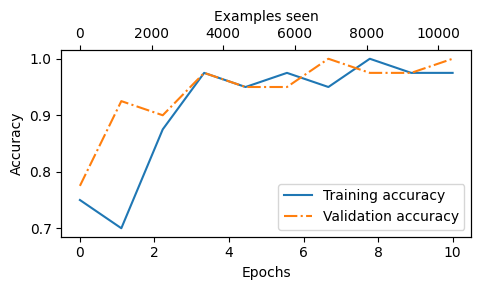

In [129]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [131]:
# Now call the trained model to get the accuracy on whole all three datasets
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model,device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 98.75%
Validation Accuracy: 97.32%
Test Accuracy: 97.33%


In [132]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

In [133]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [134]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


In [135]:
# We should also store the history values of AdamW optimizer of model, so we can store both things single time
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.01)
 
torch.save({
    "model_state_dict":model.state_dict(),
    "optimizer_state_dict":optimizer.state_dict(),
    },"Pretrained_Finetuned_LLM_model_and_optimizer.pth")


In [ ]:
# # In this way, we can train & store parameters/optimzer of our model and can import,continue training from their after.
# # Now let's import our model from the saved location
# import torch
# checkpoint = torch.load("Pretrained_Finetuned_LLM_model_and_optimizer.pth")
# model = GPTModel(NEW_CONFIG)

# model.to(device)  # Loading model to 'CUDA/GPU'

# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.01)
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# model.eval();